In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set(style="whitegrid")

# Load dataset
df = pd.read_csv('lung cancer.csv')

# Cleaning column names: remove spaces, standardize
df.columns = [col.strip().upper().replace(" ", "_") for col in df.columns]

# Show the first few rows
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [18]:
# Shape and basic info
print("Shape of dataset:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape of dataset: (309, 16)

Data types:
 GENDER                     str
AGE                      int64
SMOKING                  int64
YELLOW_FINGERS           int64
ANXIETY                  int64
PEER_PRESSURE            int64
CHRONIC_DISEASE          int64
FATIGUE                  int64
ALLERGY                  int64
WHEEZING                 int64
ALCOHOL_CONSUMING        int64
COUGHING                 int64
SHORTNESS_OF_BREATH      int64
SWALLOWING_DIFFICULTY    int64
CHEST_PAIN               int64
LUNG_CANCER                str
dtype: object

Missing values:
 GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC_DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL_CONSUMING        0
COUGHING                 0
SHORTNESS_OF_BREATH      0
SWALLOWING_DIFFICULTY    0
CHEST_PAIN               0
LUNG_CANCER              

In [19]:
# Unique values per column
df.nunique()

GENDER                    2
AGE                      39
SMOKING                   2
YELLOW_FINGERS            2
ANXIETY                   2
PEER_PRESSURE             2
CHRONIC_DISEASE           2
FATIGUE                   2
ALLERGY                   2
WHEEZING                  2
ALCOHOL_CONSUMING         2
COUGHING                  2
SHORTNESS_OF_BREATH       2
SWALLOWING_DIFFICULTY     2
CHEST_PAIN                2
LUNG_CANCER               2
dtype: int64

C:\Users\FAME\AppData\Local\Temp\ipykernel_29780\4292058996.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='LUNG_CANCER', palette='Set2')


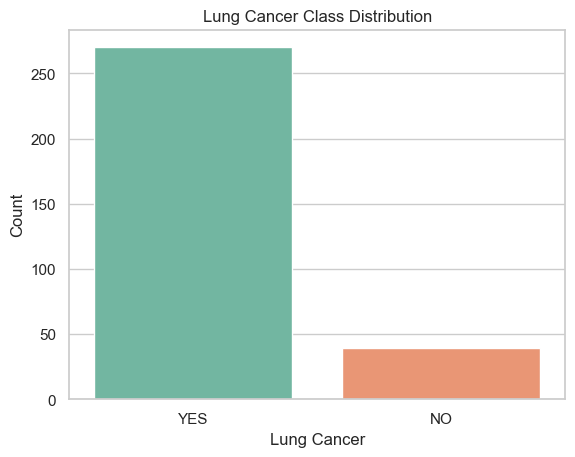

LUNG_CANCER
YES    270
NO      39
Name: count, dtype: int64

In [20]:
sns.countplot(data=df, x='LUNG_CANCER', palette='Set2')
plt.title("Lung Cancer Class Distribution")
plt.xlabel("Lung Cancer")
plt.ylabel("Count")
plt.show()

# Numerical distribution
df['LUNG_CANCER'].value_counts()

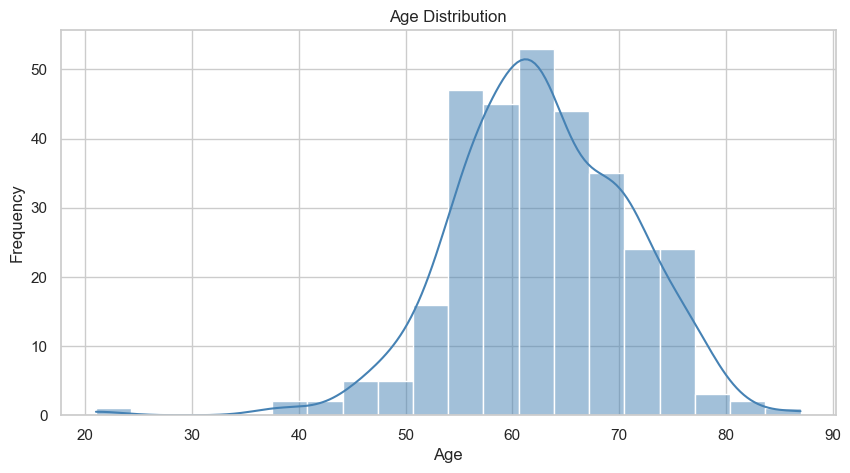

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(df['AGE'], bins=20, kde=True, color='steelblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

C:\Users\FAME\AppData\Local\Temp\ipykernel_29780\2242046042.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='GENDER', palette='coolwarm')


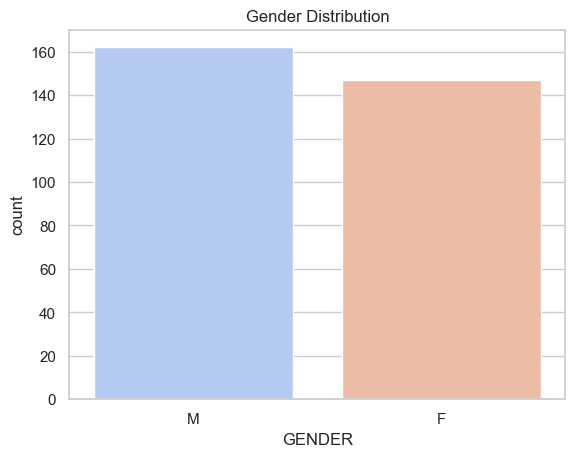

LUNG_CANCER,NO,YES
GENDER,,
F,14.965986,85.034014
M,10.493827,89.506173


In [22]:
sns.countplot(data=df, x='GENDER', palette='coolwarm')
plt.title("Gender Distribution")
plt.show()

# Crosstab with lung cancer
pd.crosstab(df['GENDER'], df['LUNG_CANCER'], normalize='index') * 100


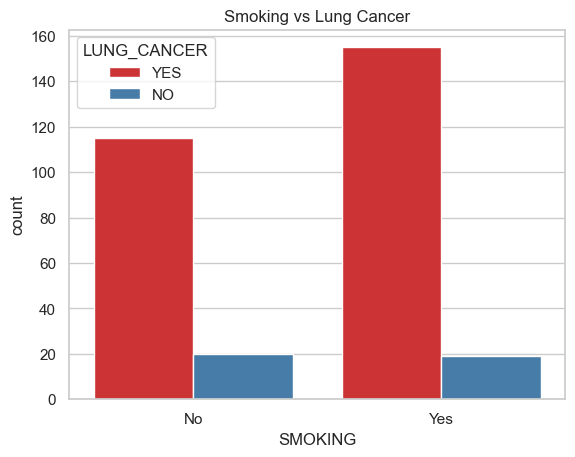

In [23]:
# Smoking vs Lung Cancer
sns.countplot(data=df, x='SMOKING', hue='LUNG_CANCER', palette='Set1')
plt.title("Smoking vs Lung Cancer")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

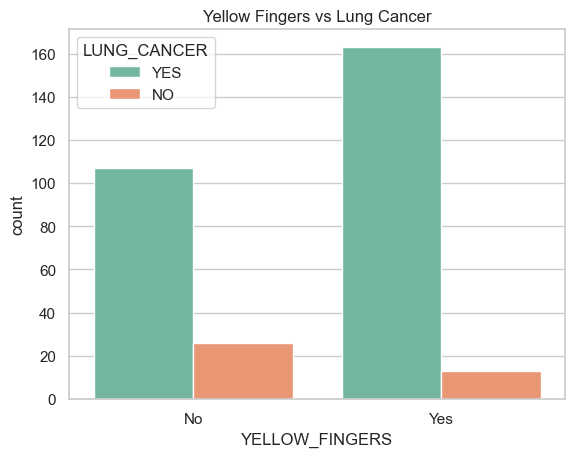

In [24]:
# Yellow Fingers
sns.countplot(data=df, x='YELLOW_FINGERS', hue='LUNG_CANCER', palette='Set2')
plt.title("Yellow Fingers vs Lung Cancer")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

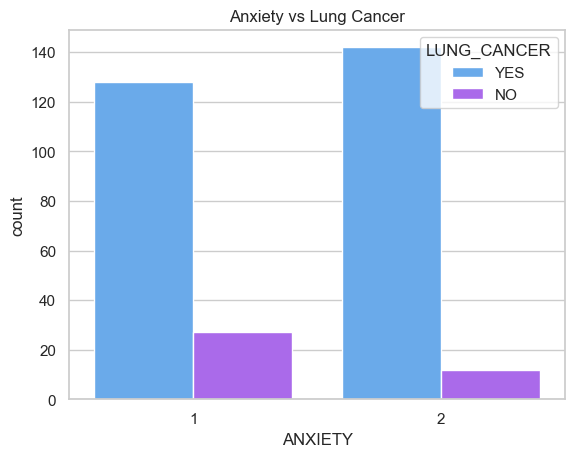

In [25]:
# Anxiety
sns.countplot(data=df, x='ANXIETY', hue='LUNG_CANCER', palette='cool')
plt.title("Anxiety vs Lung Cancer")
plt.show()

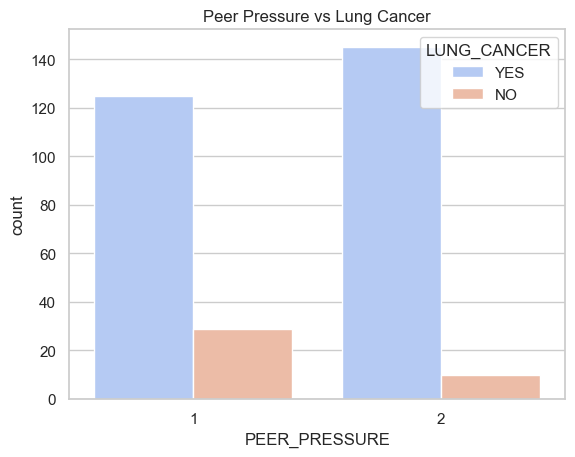

In [26]:
# Peer Pressure
sns.countplot(data=df, x='PEER_PRESSURE', hue='LUNG_CANCER', palette='coolwarm')
plt.title("Peer Pressure vs Lung Cancer")
plt.show()

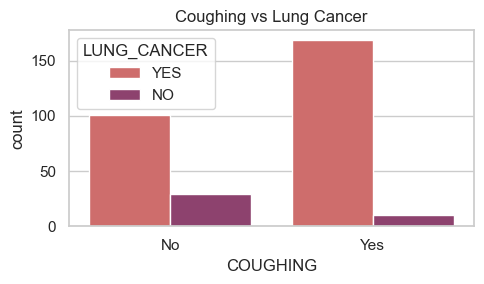

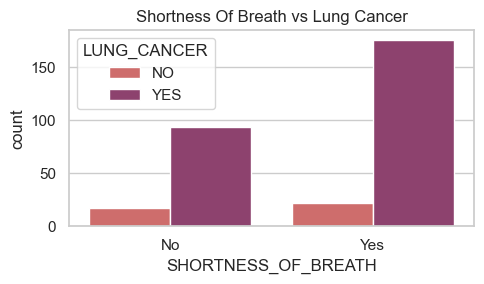

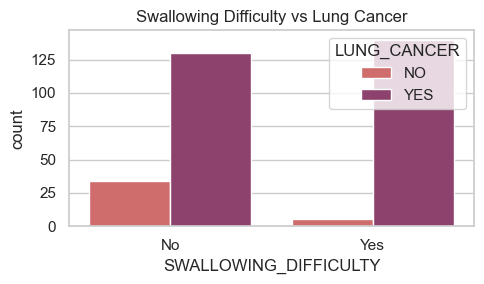

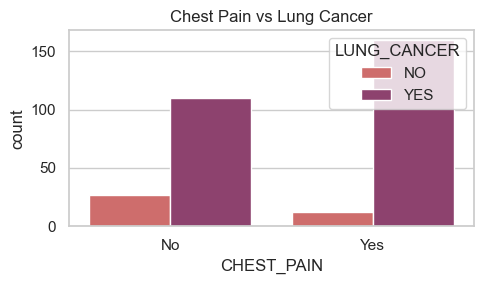

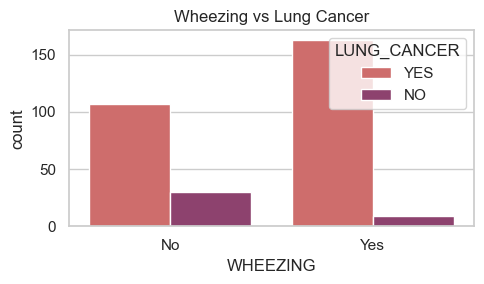

In [27]:
symptoms = ['COUGHING', 'SHORTNESS_OF_BREATH', 'SWALLOWING_DIFFICULTY', 'CHEST_PAIN', 'WHEEZING']

for col in symptoms:
    plt.figure(figsize=(5, 3))
    sns.countplot(data=df, x=col, hue='LUNG_CANCER', palette='flare')
    plt.title(f"{col.replace('_', ' ').title()} vs Lung Cancer")
    plt.xticks([0, 1], ['No', 'Yes'])
    plt.tight_layout()
    plt.show()

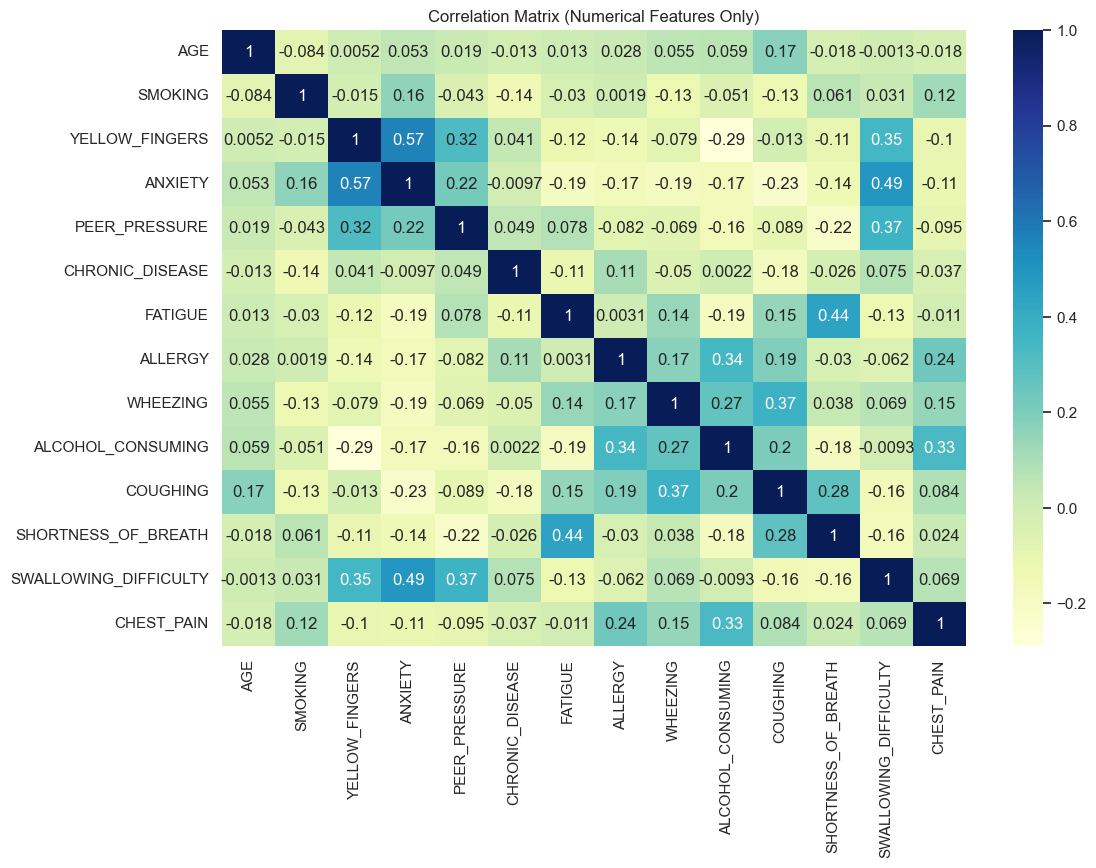

In [28]:
# Select only numeric columns before computing correlation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Now plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='YlGnBu')
plt.title("Correlation Matrix (Numerical Features Only)")
plt.show()